In [18]:
from pathlib import Path
import xarray as xr

import echopype as ep

In [2]:
path_Sv = "/Volumes/sh2506_ext1/leg1_test/Sv"
path_MVBS = "/Volumes/sh2506_ext1/leg1_test/MVBS"

In [34]:
Sv_files = sorted(list(Path(path_Sv).glob("*.zarr")))
len(Sv_files)

211

In [3]:
MVBS_files = sorted(list(Path(path_MVBS).glob("*.zarr")))
len(MVBS_files)

123

In [27]:
ds_MVBS_combine = xr.open_mfdataset(
    MVBS_files[-40:],
    parallel=True,
    coords="minimal",
    data_vars="minimal",
    compat='override',
    chunks={"channel": -1, "ping_time": -1, "depth": -1},  # load everything into 1 chunk
    engine="zarr",  # use zarr engine for reading
)

In [28]:
ds_MVBS_combine = ep.consolidate.swap_dims_channel_frequency(ds_MVBS_combine)

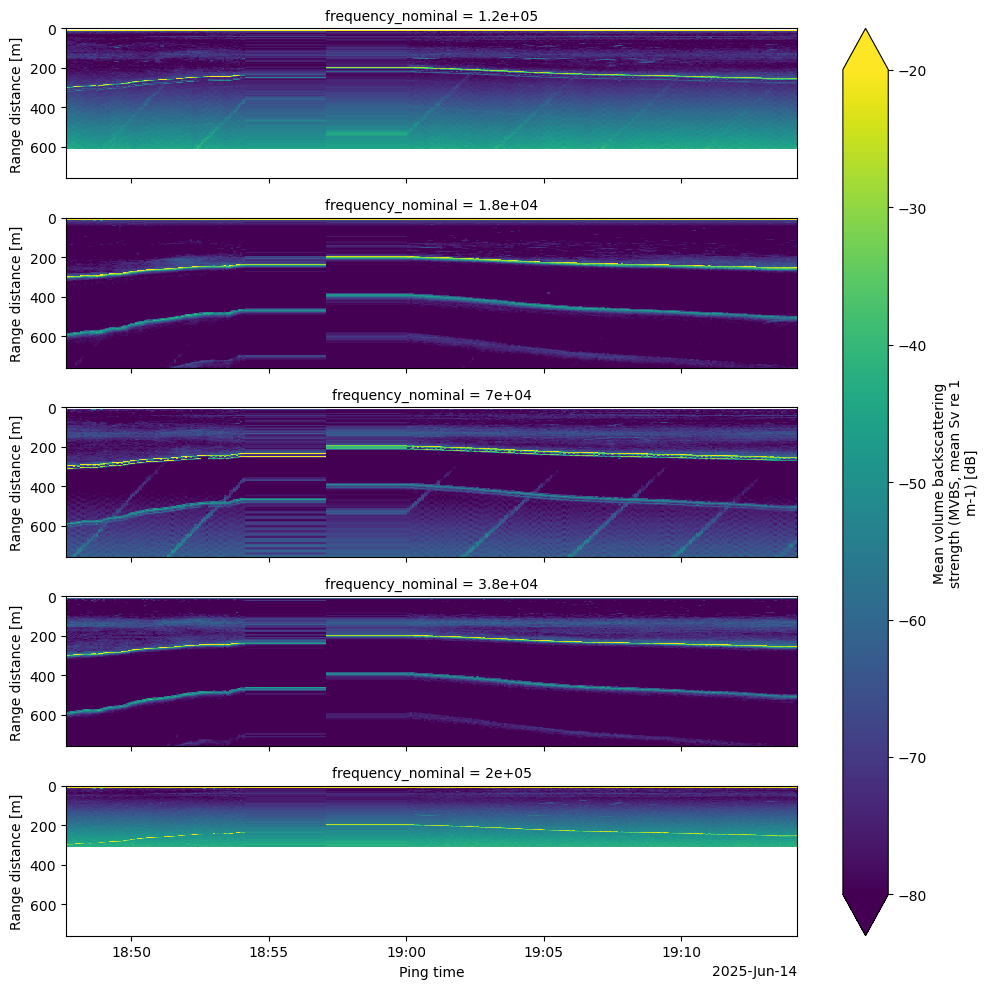

In [47]:
ds_MVBS_combine["Sv"].isel(ping_time=slice(-250, None)).plot(
    x="ping_time", y="depth",
    row="frequency_nominal", col_wrap=1,
    figsize=(10, 10),
    cmap="viridis", vmin=-80, vmax=-20, yincrease=False,
)

In [39]:
Sv_files[-15:-10]

[PosixPath('/Volumes/sh2506_ext1/leg1_test/Sv/IWCPS-D20250614-T184216_Sv.zarr'),
 PosixPath('/Volumes/sh2506_ext1/leg1_test/Sv/IWCPS-D20250614-T184716_Sv.zarr'),
 PosixPath('/Volumes/sh2506_ext1/leg1_test/Sv/IWCPS-D20250614-T185215_Sv.zarr'),
 PosixPath('/Volumes/sh2506_ext1/leg1_test/Sv/IWCPS-D20250614-T185713_Sv.zarr'),
 PosixPath('/Volumes/sh2506_ext1/leg1_test/Sv/IWCPS-D20250614-T190211_Sv.zarr')]

In [41]:
ds_Sv = xr.open_mfdataset(
    Sv_files[-15:-10],
    parallel=True,
    coords="minimal",
    data_vars="minimal",
    compat='override',
    chunks={"channel": 1, "ping_time": 1000, "range_sample": -1},
    engine="zarr",  # use zarr engine for reading
)

In [43]:
ds_Sv = ep.consolidate.swap_dims_channel_frequency(ds_Sv)

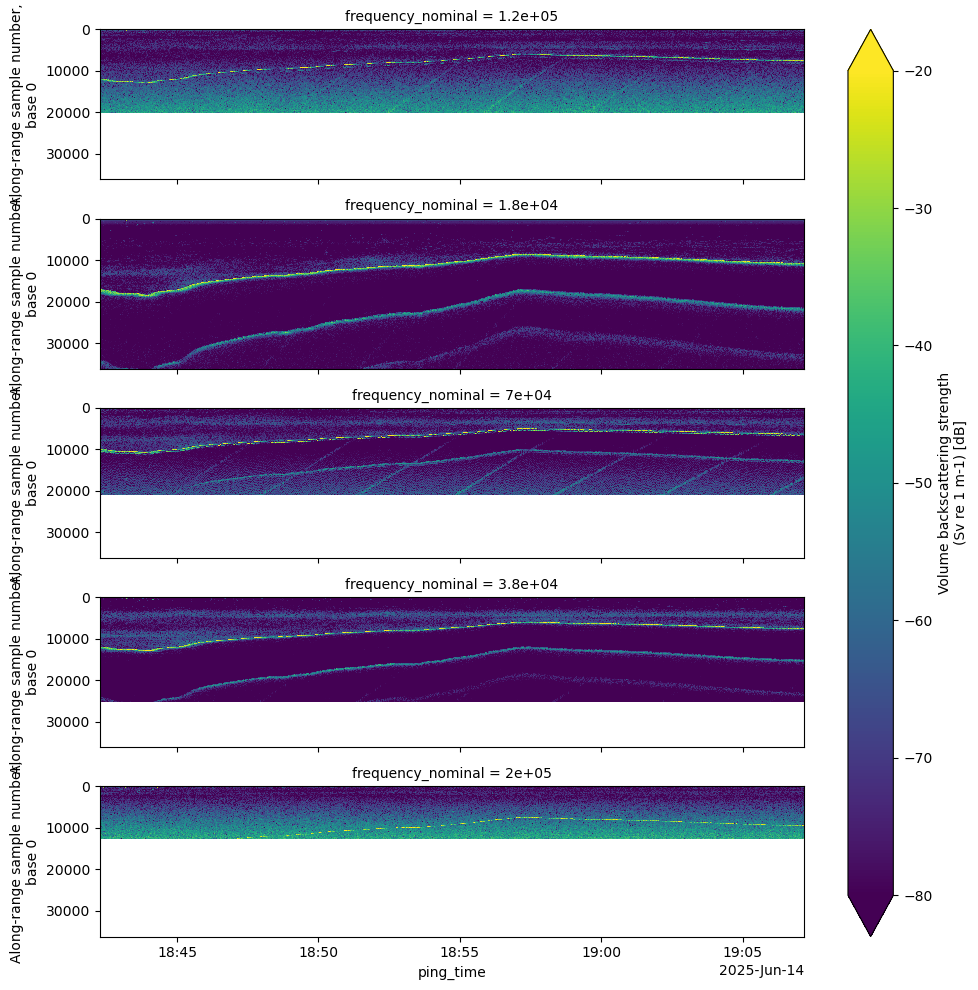

In [45]:
ds_Sv["Sv"].plot(
    x="ping_time", y="range_sample",
    row="frequency_nominal", col_wrap=1,
    figsize=(10, 10),
    cmap="viridis", vmin=-80, vmax=-20, yincrease=False,
)

In [49]:
MVBS_files[-20:]

[PosixPath('/Volumes/sh2506_ext1/leg1_test/MVBS/MVBS_20250614T160000.zarr'),
 PosixPath('/Volumes/sh2506_ext1/leg1_test/MVBS/MVBS_20250614T161000.zarr'),
 PosixPath('/Volumes/sh2506_ext1/leg1_test/MVBS/MVBS_20250614T162000.zarr'),
 PosixPath('/Volumes/sh2506_ext1/leg1_test/MVBS/MVBS_20250614T163000.zarr'),
 PosixPath('/Volumes/sh2506_ext1/leg1_test/MVBS/MVBS_20250614T164000.zarr'),
 PosixPath('/Volumes/sh2506_ext1/leg1_test/MVBS/MVBS_20250614T165000.zarr'),
 PosixPath('/Volumes/sh2506_ext1/leg1_test/MVBS/MVBS_20250614T170000.zarr'),
 PosixPath('/Volumes/sh2506_ext1/leg1_test/MVBS/MVBS_20250614T171000.zarr'),
 PosixPath('/Volumes/sh2506_ext1/leg1_test/MVBS/MVBS_20250614T172000.zarr'),
 PosixPath('/Volumes/sh2506_ext1/leg1_test/MVBS/MVBS_20250614T173000.zarr'),
 PosixPath('/Volumes/sh2506_ext1/leg1_test/MVBS/MVBS_20250614T174000.zarr'),
 PosixPath('/Volumes/sh2506_ext1/leg1_test/MVBS/MVBS_20250614T175000.zarr'),
 PosixPath('/Volumes/sh2506_ext1/leg1_test/MVBS/MVBS_20250614T180000.zarr'),

In [50]:
xr.open_dataset(MVBS_files[-1], engine="zarr")

<xarray.Dataset> Size: 2MB
Dimensions:            (channel: 5, ping_time: 51, depth: 760)
Coordinates:
  * channel            (channel) <U25 500B 'WBT 400140-15 ES120-7C_ES' ... 'W...
  * depth              (depth) float64 6kB 0.0 1.0 2.0 3.0 ... 757.0 758.0 759.0
  * ping_time          (ping_time) datetime64[ns] 408B 2025-06-14T19:10:00 .....
Data variables:
    Sv                 (channel, ping_time, depth) float64 2MB ...
    frequency_nominal  (channel) float64 40B ...
    latitude           (ping_time) float64 408B ...
    longitude          (ping_time) float64 408B ...
Attributes:
    processing_function:          commongrid.compute_MVBS
    processing_level:             Level 3A
    processing_level_url:         https://echopype.readthedocs.io/en/stable/p...
    processing_software_name:     echopype
    processing_software_version:  0.10.1
    processing_time:              2025-06-14T19:33:00Z

In [51]:
xr.open_dataset(MVBS_files[-2], engine="zarr")

<xarray.Dataset> Size: 4MB
Dimensions:            (channel: 5, ping_time: 120, depth: 760)
Coordinates:
  * channel            (channel) <U25 500B 'WBT 400140-15 ES120-7C_ES' ... 'W...
  * depth              (depth) float64 6kB 0.0 1.0 2.0 3.0 ... 757.0 758.0 759.0
  * ping_time          (ping_time) datetime64[ns] 960B 2025-06-14T19:00:00 .....
Data variables:
    Sv                 (channel, ping_time, depth) float64 4MB ...
    frequency_nominal  (channel) float64 40B ...
    latitude           (ping_time) float64 960B ...
    longitude          (ping_time) float64 960B ...
Attributes:
    processing_function:          commongrid.compute_MVBS
    processing_level:             Level 3A
    processing_level_url:         https://echopype.readthedocs.io/en/stable/p...
    processing_software_name:     echopype
    processing_software_version:  0.10.1
    processing_time:              2025-06-14T19:23:01Z

In [52]:
xr.open_dataset(MVBS_files[-3], engine="zarr")

<xarray.Dataset> Size: 2MB
Dimensions:            (channel: 5, ping_time: 51, depth: 760)
Coordinates:
  * channel            (channel) <U25 500B 'WBT 400140-15 ES120-7C_ES' ... 'W...
  * depth              (depth) float64 6kB 0.0 1.0 2.0 3.0 ... 757.0 758.0 759.0
  * ping_time          (ping_time) datetime64[ns] 408B 2025-06-14T18:50:00 .....
Data variables:
    Sv                 (channel, ping_time, depth) float64 2MB ...
    frequency_nominal  (channel) float64 40B ...
    latitude           (ping_time) float64 408B ...
    longitude          (ping_time) float64 408B ...
Attributes:
    processing_function:          commongrid.compute_MVBS
    processing_level:             Level 3A
    processing_level_url:         https://echopype.readthedocs.io/en/stable/p...
    processing_software_name:     echopype
    processing_software_version:  0.10.1
    processing_time:              2025-06-14T19:13:03Z

In [53]:
xr.open_dataset(MVBS_files[-4], engine="zarr")

<xarray.Dataset> Size: 4MB
Dimensions:            (channel: 5, ping_time: 120, depth: 760)
Coordinates:
  * channel            (channel) <U25 500B 'WBT 400140-15 ES120-7C_ES' ... 'W...
  * depth              (depth) float64 6kB 0.0 1.0 2.0 3.0 ... 757.0 758.0 759.0
  * ping_time          (ping_time) datetime64[ns] 960B 2025-06-14T18:40:00 .....
Data variables:
    Sv                 (channel, ping_time, depth) float64 4MB ...
    frequency_nominal  (channel) float64 40B ...
    latitude           (ping_time) float64 960B ...
    longitude          (ping_time) float64 960B ...
Attributes:
    processing_function:          commongrid.compute_MVBS
    processing_level:             Level 3A
    processing_level_url:         https://echopype.readthedocs.io/en/stable/p...
    processing_software_name:     echopype
    processing_software_version:  0.10.1
    processing_time:              2025-06-14T19:03:01Z

In [54]:
xr.open_dataset(MVBS_files[-5], engine="zarr")

<xarray.Dataset> Size: 2MB
Dimensions:            (channel: 5, ping_time: 51, depth: 760)
Coordinates:
  * channel            (channel) <U25 500B 'WBT 400140-15 ES120-7C_ES' ... 'W...
  * depth              (depth) float64 6kB 0.0 1.0 2.0 3.0 ... 757.0 758.0 759.0
  * ping_time          (ping_time) datetime64[ns] 408B 2025-06-14T18:30:00 .....
Data variables:
    Sv                 (channel, ping_time, depth) float64 2MB ...
    frequency_nominal  (channel) float64 40B ...
    latitude           (ping_time) float64 408B ...
    longitude          (ping_time) float64 408B ...
Attributes:
    processing_function:          commongrid.compute_MVBS
    processing_level:             Level 3A
    processing_level_url:         https://echopype.readthedocs.io/en/stable/p...
    processing_software_name:     echopype
    processing_software_version:  0.10.1
    processing_time:              2025-06-14T18:53:01Z